# 01 — Chunking strategy

Justify the choice of `chonkie.RecursiveChunker(tokenizer="gpt2", chunk_size=256)`
for GaRAG and measure the resulting distribution on the 2 495-document corpus.

**TL;DR.** We pick **Recursive 256/gpt2** for three reasons:

1. Our corpus is a mix of long structured text (MITRE ATT&CK, OWASP, man pages) and
   short one-line metadata (HackerOne). A recursive splitter degrades gracefully
   both ways.
2. 256 gpt2 tokens ≈ 200–250 words — fits comfortably in the bge-m3 context
   window (8 192) and leaves room for top-k retrieval without truncation.
3. gpt2 tokenizer matches what BM25 and the reranker see more closely than
   character-level splits.

Alternatives (fixed-size, semantic, entity-aware) are compared below.

## 1. Alternatives considered

| Strategy | Pro | Con | Verdict |
|---|---|---|---|
| **Fixed-size (tokens)** | Simplest, uniform chunk lengths | Cuts sentences mid-way, hurts BM25 term locality | rejected |
| **Fixed-size (characters)** | Fastest | Token count drifts per source, bge-m3 context hard to predict | rejected |
| **RecursiveChunker 256 gpt2** | Respects paragraph → sentence → punctuation hierarchy; uniform token budget | Slightly more CPU than fixed | **selected** |
| **SemanticChunker** | Best semantic boundaries | Requires an extra embedding pass over the whole corpus; adds ~2 min to indexing; marginal retrieval gains on structured sources | rejected for MVP, revisited in future work |
| **Per-entity (STIX objects, OWASP sections)** | Preserves atomic units | Would require 5 custom parsers and lose consistency across sources | rejected |

Future work (see `docs/roadmap.md`) will run E2 — a
proper benchmark of Recursive vs Semantic vs per-entity chunking on the golden
set, so this decision is reopenable.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
CHUNKS = ROOT / 'data' / 'processed' / 'chunks.parquet'
DOCS = ROOT / 'data' / 'raw' / 'documents.parquet'
CONFIG = ROOT / 'data' / 'processed' / 'chunks.config.json'

chunks = pd.read_parquet(CHUNKS)
docs = pd.read_parquet(DOCS)
config = json.loads(CONFIG.read_text())
print(f'chunker config: {config}')
print(f'chunks: {len(chunks)}, docs: {len(docs)}')

chunker config: {'chunker': 'RecursiveChunker', 'tokenizer': 'gpt2', 'chunk_size': 256, 'source_file': 'documents.parquet', 'documents_in': 2495, 'chunks_out': 3779, 'per_source': {'mitre_attack': 2460, 'mitre_atlas': 439, 'owasp': 110, 'hackerone': 500, 'man_pages': 270}}
chunks: 3779, docs: 2495


## 2. Chunks per source


In [2]:
per_source = pd.DataFrame(
    {
        'docs': docs.groupby('source').size(),
        'chunks': chunks.groupby('source').size(),
    }
)
per_source['fanout'] = (per_source['chunks'] / per_source['docs']).round(2)
per_source['tokens_mean'] = (
    chunks.groupby('source')['token_count'].mean().round(0).astype(int)
)
per_source['tokens_median'] = chunks.groupby('source')['token_count'].median().astype(int)
per_source.loc['TOTAL'] = [
    len(docs),
    len(chunks),
    round(len(chunks) / len(docs), 2),
    int(chunks['token_count'].mean()),
    int(chunks['token_count'].median()),
]
per_source

,docs,chunks,fanout,tokens_mean,tokens_median
source,,,,,
hackerone,500.0,500.0,1.00,40.0,39.0
man_pages,5.0,270.0,54.00,238.0,246.0
mitre_atlas,275.0,439.0,1.60,163.0,175.0
mitre_attack,1705.0,2460.0,1.44,143.0,138.0
owasp,10.0,110.0,11.00,219.0,239.0
TOTAL,2495.0,3779.0,1.51,140.0,136.0


## 3. Token count distribution


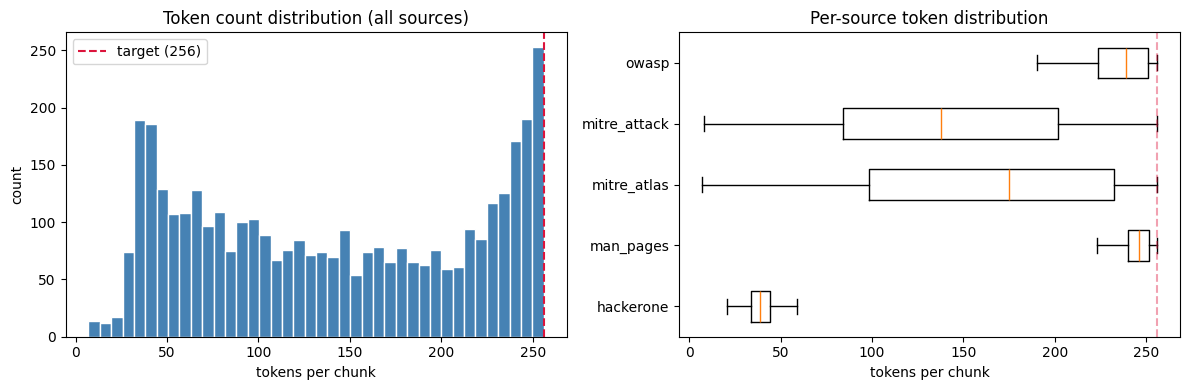

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
hackerone,500.0,40.0,9.0,21.0,34.0,39.0,44.0,143.0
man_pages,270.0,238.0,31.0,23.0,240.0,246.0,252.0,256.0
mitre_atlas,439.0,163.0,71.0,7.0,98.0,175.0,232.0,256.0
mitre_attack,2460.0,143.0,66.0,8.0,84.0,138.0,202.0,256.0
owasp,110.0,219.0,50.0,34.0,224.0,239.0,251.0,256.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: overall histogram
axes[0].hist(chunks['token_count'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(256, color='crimson', linestyle='--', label='target (256)')
axes[0].set_xlabel('tokens per chunk')
axes[0].set_ylabel('count')
axes[0].set_title('Token count distribution (all sources)')
axes[0].legend()

# right: per-source violin / box
sources = sorted(chunks['source'].unique())
data = [chunks[chunks['source'] == s]['token_count'].values for s in sources]
axes[1].boxplot(data, tick_labels=sources, vert=False, showfliers=False)
axes[1].axvline(256, color='crimson', linestyle='--', alpha=0.4)
axes[1].set_xlabel('tokens per chunk')
axes[1].set_title('Per-source token distribution')

plt.tight_layout()
plt.show()

chunks.groupby('source')['token_count'].describe().round(0)

## 4. Where chunks land relative to the 256 target


In [4]:
buckets = pd.cut(
    chunks['token_count'],
    bins=[0, 32, 64, 128, 192, 224, 256, 512],
    labels=['≤32', '33-64', '65-128', '129-192', '193-224', '225-256', '>256'],
)
bucket_counts = buckets.value_counts().sort_index()
print(bucket_counts.to_string())
print(
    f'\nshare of chunks in [193, 256]: '
    f'{((chunks["token_count"] >= 193) & (chunks["token_count"] <= 256)).mean():.1%}'
)
print(
    f'share of chunks ≤32 tokens (too small, likely metadata): '
    f'{(chunks["token_count"] <= 32).mean():.1%}'
)

token_count
≤32        143
33-64      713
65-128     939
129-192    742
193-224    386
225-256    856
>256         0

share of chunks in [193, 256]: 32.9%
share of chunks ≤32 tokens (too small, likely metadata): 3.8%


## 5. Top 10 documents by chunk count (where does the corpus density sit?)


In [5]:
top = (
    chunks.groupby(['doc_id', 'source', 'title'])
    .size()
    .reset_index(name='chunks')
    .sort_values('chunks', ascending=False)
    .head(10)
)
top[['doc_id', 'source', 'chunks', 'title']]

,doc_id,source,chunks,title
502,man_pages:nmap,man_pages,170,nmap — Network exploration tool and security /...
503,man_pages:nuclei,man_pages,82,"nuclei — fast, template-based vulnerability sc..."
2488,owasp:A04_2021-Insecure_Design,owasp,15,A04:2021 – Insecure Design
2486,owasp:A02_2021-Cryptographic_Failures,owasp,15,A02:2021 – Cryptographic Failures
2487,owasp:A03_2021-Injection,owasp,14,A03:2021 – Injection
531,mitre_atlas:AML.CS0026,mitre_atlas,13,Financial Transaction Hijacking with M365 Copi...
2485,owasp:A01_2021-Broken_Access_Control,owasp,12,A01:2021 – Broken Access Control
2491,owasp:A07_2021-Identification_and_Authenticati...,owasp,11,A07:2021 – Identification and Authentication F...
2489,owasp:A05_2021-Security_Misconfiguration,owasp,11,A05:2021 – Security Misconfiguration
556,mitre_atlas:AML.CS0051,mitre_atlas,9,OpenClaw Command & Control via Prompt Injection


## 6. Sample chunks (1 per source)


In [6]:
for src in sorted(chunks['source'].unique()):
    sample = chunks[chunks['source'] == src].sample(1, random_state=42).iloc[0]
    print(f'\n===== {src} =====')
    print(f"chunk_id:    {sample['chunk_id']}")
    print(f"title:       {sample['title'][:80]}")
    print(f"tokens:      {sample['token_count']}")
    print(f"char range:  [{sample['char_start']}, {sample['char_end']})")
    print(f"text:        {sample['text'][:400]!r}...")


===== hackerone =====
chunk_id:    hackerone:2051931::0
title:       Blind SQL injection on id.indrive.com
tokens:      37
char range:  [0, 134)
text:        'Blind SQL Injection in inDrive. Report title: Blind SQL injection on id.indrive.com Disclosed on HackerOne, 193 upvotes, $4134 bounty.'...

===== man_pages =====
chunk_id:    man_pages:nmap::18
title:       nmap — Network exploration tool and security / port scanner
tokens:      252
char range:  [13809, 14692)
text:        " address or hostname or with CIDR notation for subnets. Octet ranges aren't\n yet supported for IPv6.\n\nIPv6 addresses with non-global scope need to have a zone ID\n suffix. On Unix systems, this is a percent sign followed by an interface\n name; a complete address might be fe80::a8bb:ccff:fedd:eeff%eth0. On\n Windows, use an interface index number in place of an interface name:\n fe80::a8bb:ccff:fedd:e"...

===== mitre_atlas =====
chunk_id:    mitre_atlas:AML.CS0003::1
title:       Bypassing Cylance's AI Ma

## 7. Sanity checks


In [7]:
assert chunks['chunk_id'].is_unique, 'chunk_id not unique'
assert (chunks['token_count'] >= 1).all(), 'non-positive token_count'
assert (chunks['char_end'] >= chunks['char_start']).all(), 'char_end < char_start'
assert chunks['doc_id'].isin(docs['doc_id']).all(), 'dangling doc_id'
# Every document that produced at least one chunk should be traceable back.
orphans = docs[~docs['doc_id'].isin(chunks['doc_id'])]
print(f'documents with zero chunks: {len(orphans)}')
print('all sanity checks passed' if len(orphans) == 0 else f'orphans: {orphans["doc_id"].tolist()[:5]}')

documents with zero chunks: 0
all sanity checks passed
